#Object Detection using YOLOV8

##Generate your kaggle token from profile and upload the json file in the cell below

In [4]:
from google.colab import files
files.upload()  # Upload kaggle.json here


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"muhammadumairsafdar","key":"6790576ba6ae25e9fa4fe36c6959926e"}'}

##Create a directory for kaggle datasets

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

##Download the required dataset

In [6]:
!kaggle datasets download -d alincijov/self-driving-cars
!unzip self-driving-cars.zip -d self-driving-cars/

Streaming output truncated to the last 5000 lines.
  inflating: self-driving-cars/images/1479502279230178611.jpg  
  inflating: self-driving-cars/images/1479502279730506173.jpg  
  inflating: self-driving-cars/images/1479502280230536426.jpg  
  inflating: self-driving-cars/images/1479502280730839737.jpg  
  inflating: self-driving-cars/images/1479502281729824146.jpg  
  inflating: self-driving-cars/images/1479502282229848985.jpg  
  inflating: self-driving-cars/images/1479502282730102580.jpg  
  inflating: self-driving-cars/images/1479502283731724690.jpg  
  inflating: self-driving-cars/images/1479502284232432719.jpg  
  inflating: self-driving-cars/images/1479502285221790200.jpg  
  inflating: self-driving-cars/images/1479502285730163274.jpg  
  inflating: self-driving-cars/images/1479502286231098378.jpg  
  inflating: self-driving-cars/images/1479502287230097438.jpg  
  inflating: self-driving-cars/images/1479502287730246905.jpg  
  inflating: self-driving-cars/images/147950228823126

<div style="border-radius:10px; border:#f79a05 solid; padding: 15px; background-color: #f5d77f; font-size:100%; text-align:left">

<h3 align="left"><font color='#f79a05'>💡 Inspiration:</font></h3>
    
**Purpose**: to object detection in images by using **YOLOv8**.

**Object detection** is a computer technology related to computer vision and image processing that deals with detecting instances of semantic objects of a certain class (such as humans, buildings, or cars) in digital images and videos.
When it comes to object detection, popular detection frameworks are

* YOLO
* SSD
* Faster R-CNN


# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> What is YOLO exactly?</p>

<div style="border-radius:10px; border:#f79a05 solid; padding: 15px; background-color: #f5d77f; font-size:100%; text-align:left">

<h3 align="left"><font color='black'>What is YOLO exactly?</font></h3>
    
**YOLO** (You Only Look Once) is a method / way to do object detection. It is the algorithm /strategy behind how the code is going to detect objects in the image.

Earlier detection frameworks, looked at different parts of the image multiple times at different scales and repurposed image classification technique to detect objects. This approach is slow and inefficient.

YOLO takes entirely different approach. It looks at the entire image only once and goes through the network once and detects objects. Hence the name. It is very fast. That’s the reason it has got so popular.

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Import Libraries</p>

In [7]:
import numpy as np
import pandas as pd
import cv2

from sklearn.utils import shuffle
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

import warnings

warnings.simplefilter('ignore')

### <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Load data</p>

In [8]:
df = pd.read_csv('self-driving-cars/labels_train.csv')
df = shuffle(df)
df.head()

,frame,xmin,xmax,ymin,ymax,class_id
87731,1479502126721663763.jpg,145,196,122,169,1
36298,1478896780402409782.jpg,94,120,147,171,1
84644,1479501821698955509.jpg,227,270,129,173,1
127143,1479505752963393906.jpg,134,163,135,161,1
49639,1478897874422308532.jpg,2,18,151,177,4


<div style="border-radius:10px; border:#f79a05 solid; padding: 15px; background-color: #f5d77f; font-size:100%; text-align:left">
    
 * This dataset is mostly a practice and training aspect for the subject of YOLO. The data is labeled with 5 classes.
 * classic_id labels: 'car', 'truck', 'pedestrian', 'bicyclist', 'light'

In [9]:
classes = df.class_id.unique()
print(classes)

[1 4 2 3 5]


In [10]:
labels = { 1:'car', 2:'truck', 3:'person', 4:'bicycle', 5:'traffic light'}

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Show some labeled images</p>

In [11]:
# Get path images and boxes (x,y) for each class_id
boxes = {}
images = {}

base_path = 'self-driving-cars/images/'

for class_id in classes:
    first_row = df[df['class_id'] == class_id].iloc[0]

    images[class_id] = cv2.imread(base_path + first_row['frame'])
    boxes[class_id] = [first_row['xmin'],first_row['xmax'],first_row['ymin'],first_row['ymax']]

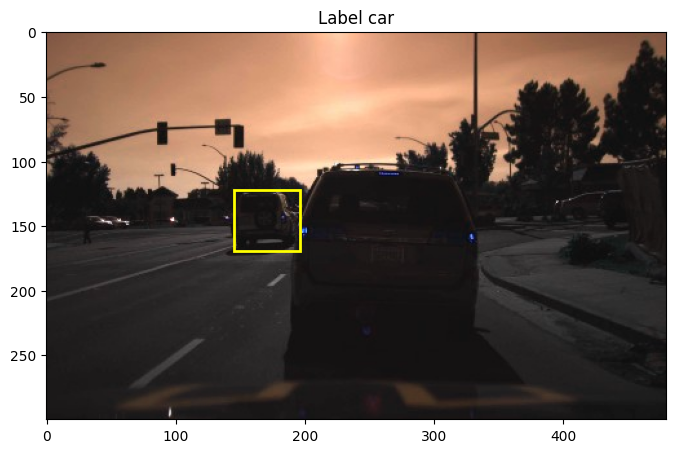

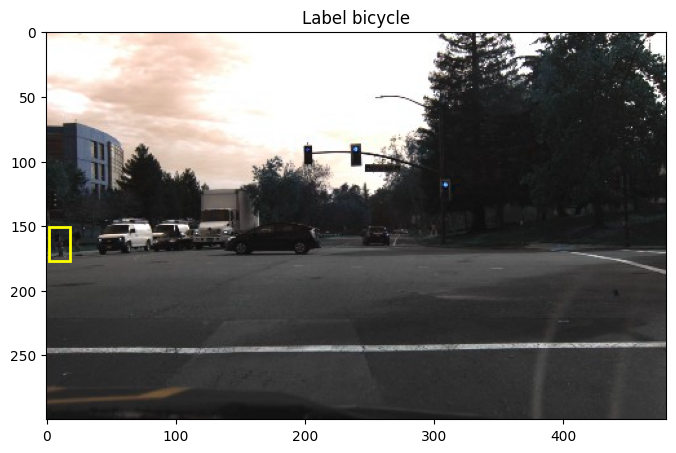

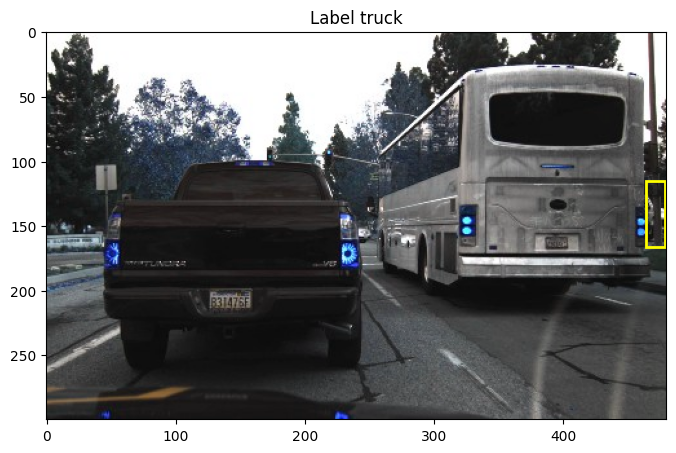

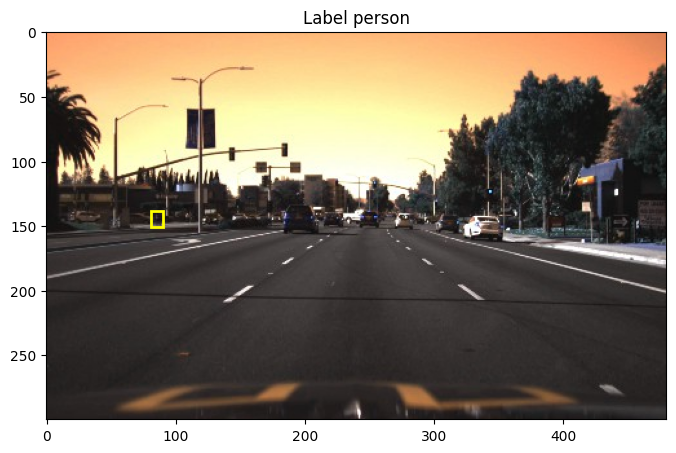

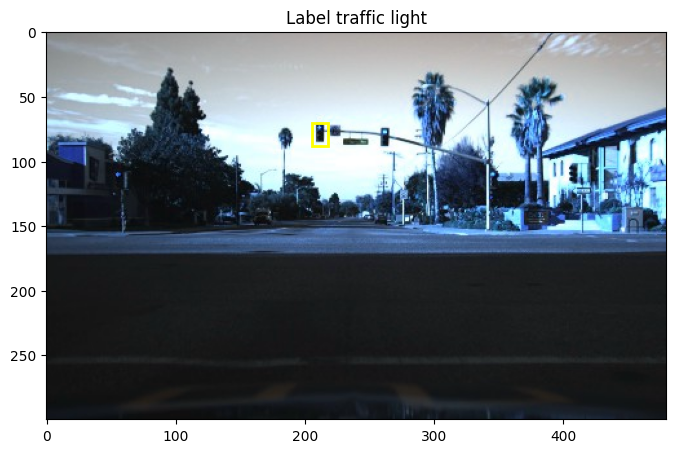

In [12]:
for i in classes:

    xmin, xmax, ymin, ymax = boxes[i][0], boxes[i][1], boxes[i][2], boxes[i][3]

    plt.figure(figsize=(8, 10))
    plt.title("Label " + labels[i])
    plt.imshow(images[i])
    plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, color='yellow', fill=False, linewidth=2))

    plt.show()

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Model</p>

In [13]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.0 MB/s eta 0:00:00


In [14]:
from ultralytics import YOLO
import PIL
from PIL import Image
from IPython.display import display
import os
import pathlib

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [15]:
model = YOLO("yolov8m.pt")

In [16]:
results=model.predict(source="self-driving-cars/images/1478019956680248165.jpg",
              save=True, conf=0.2,iou=0.5)


image 1/1 /content/self-driving-cars/images/1478019956680248165.jpg: 416x640 1 car, 1 truck, 33.7ms
Speed: 70.9ms preprocess, 33.7ms inference, 78.5ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict


In [17]:
result = results[0]
box = result.boxes[0]

In [18]:
for result in results:
    boxes = result.boxes  # Boxes object for bbox outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    probs = result.probs  # Class probabilities for classification outputs

In [19]:
cords = box.xyxy[0].tolist()
class_id = box.cls[0].item()
conf = box.conf[0].item()
print("Object type:", class_id)
print("Coordinates:", cords)
print("Probability:", conf)

Object type: 2.0
Coordinates: [124.69143676757812, 142.68826293945312, 148.7809295654297, 162.10049438476562]
Probability: 0.7161705493927002


In [20]:
for box in result.boxes:
    class_id = result.names[box.cls[0].item()]
    cords = box.xyxy[0].tolist()
    cords = [round(x) for x in cords]
    conf = round(box.conf[0].item(), 2)
    print("Object type:", class_id)
    print("Coordinates:", cords)
    print("Probability:", conf)
    print("---")

Object type: car
Coordinates: [125, 143, 149, 162]
Probability: 0.72
---
Object type: truck
Coordinates: [141, 139, 157, 154]
Probability: 0.31
---


In [21]:
results1 = model.predict(source="self-driving-cars/images/1478020211690815798.jpg",
              save=True, conf=0.2,iou=0.5)

Results = results1[0]


image 1/1 /content/self-driving-cars/images/1478020211690815798.jpg: 416x640 4 cars, 3 traffic lights, 26.9ms
Speed: 5.1ms preprocess, 26.9ms inference, 5.7ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict


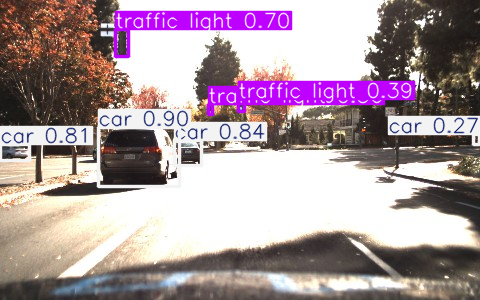

In [22]:
# Plotting results
plot = results1[0].plot()
plot = cv2.cvtColor(plot, cv2.COLOR_BGR2RGB)
display(Image.fromarray(plot))

##Exercise (Object-Detection Visualization)
**Using the concepts from the notebook—loading annotations from a CSV, reading images, and drawing bounding boxes—write a short script that:**

1. Loads the labels_train.csv into a pandas DataFrame.

2. Randomly selects one image filename from the DataFrame.

3. Reads its image file from self-driving-cars/images/.

4. Filters the DataFrame to get all bounding-box annotations for that image (columns: xmin, ymin, xmax, ymax and class).

5. Draws each box (and class label) onto the image using PIL.ImageDraw.

6. Displays the resulting annotated image.



Selected Image: 1479498585480019008.jpg


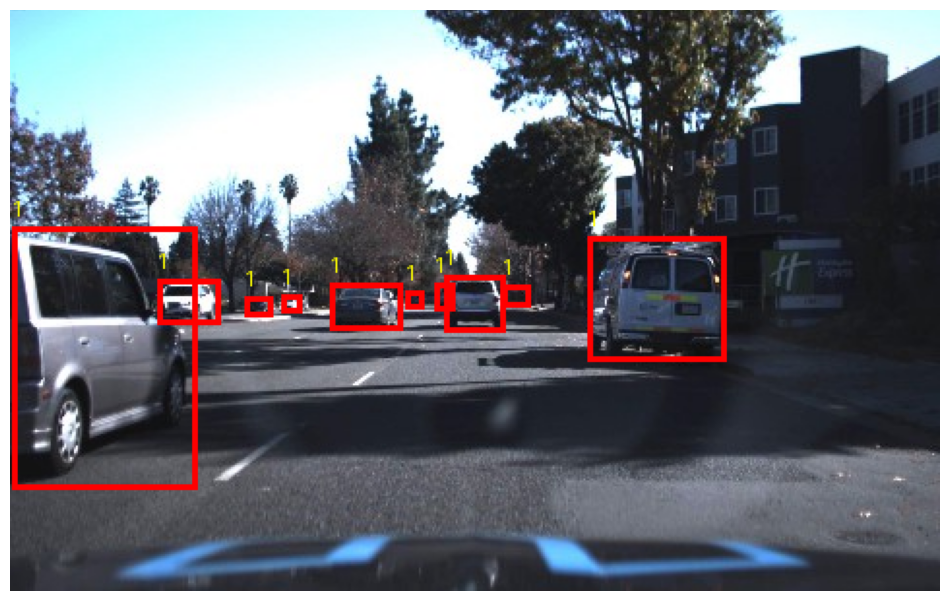

In [30]:
import pandas as pd
import random
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("/content/self-driving-cars/labels_train.csv")

# Select random image
frame_name = random.choice(df["frame"].unique())

print("Selected Image:", frame_name)

# Load image
image = Image.open(f"/content/self-driving-cars/images/{frame_name}")

# Filter annotations
annotations = df[df["frame"] == frame_name]

# Create drawing object
draw = ImageDraw.Draw(image)

# Draw boxes
for _, row in annotations.iterrows():

    xmin = int(row["xmin"])
    xmax = int(row["xmax"])
    ymin = int(row["ymin"])
    ymax = int(row["ymax"])

    class_id = int(row["class_id"])

    draw.rectangle(
        [(xmin, ymin), (xmax, ymax)],
        outline="red",
        width=3
    )

    draw.text(
        (xmin, ymin-15),
        str(class_id),
        fill="yellow"
    )

plt.figure(figsize=(12,8))
plt.imshow(image)
plt.axis("off")
plt.show()